## Cómo interactuar con este cuaderno de Jupyter

En esta actividad, utilizarás un cuaderno de Jupyter, que integra tanto texto como código. Las cajas grises contienen código ejecutable, que ejecutarás para ver su salida. El texto entre el código proporciona instrucciones.


# Proyecto: Generación de Datos Sintéticos


## Paso 1: Importar bibliotecas
Ejecute la celda a continuación.


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    roc_curve,
)

# Import SMOTE
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

## Paso 2: Cargar el conjunto de datos en un DataFrame de pandas

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [2]:
# insert code here 

# Use .read_csv() to load the 'diabetes.csv' file into a DataFrame named 'diabetes_data'.
# insert code here 
# Use .read_csv() to load the 'diabetes.csv' file into a DataFrame named 'diabetes_data'.
diabetes_data = pd.read_csv('diabetes.csv')


## Paso 3: Verificar las dimensiones de los datos

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [3]:
# Display the shape of the DataFrame (rows, columns)
print("\nShape of the DataFrame (rows, columns):", diabetes_data.shape)


Shape of the DataFrame (rows, columns): (768, 9)


## Paso 4: Vista previa de los datos

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [4]:
# Use head() to preview the diabetes_data DataFrame 
# insert code here 
# Use head() to preview the diabetes_data DataFrame 
diabetes_data.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Paso 5: Obtener un resumen de los datos

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [4]:
# Use info() to see detailed information about the diabetes_data DataFrame.
# insert code here 
diabetes_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Paso 6: Verificar datos faltantes

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [5]:
# Check for missing values
# insert code here 
diabetes_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

It looks like our dataset is complete and has zeros for all columns. The dataset has the following features:

- **Embarazos**: Número de veces embarazada
- **Glucosa**: Concentración de glucosa en plasma
- **PresiónArterial**: Presión arterial diastólica (mm Hg)
- **GrosorPiel**: Grosor del pliegue cutáneo del tríceps (mm)
- **Insulina**: Insulina sérica de 2 horas (mu U/ml)
- **IMC**: Índice de masa corporal (peso en kg/(altura en m)^2)
- **FuncionPedigreeDiabetes**: Función de pedigrí de diabetes
- **Edad**: Edad (años)
- **Resultado**: Variable de clase (0 o 1), donde 1 significa que el paciente tiene diabetes


## Paso 7: Analizando la distribución de clases para desequilibrio

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


Text(0, 0.5, 'Count')

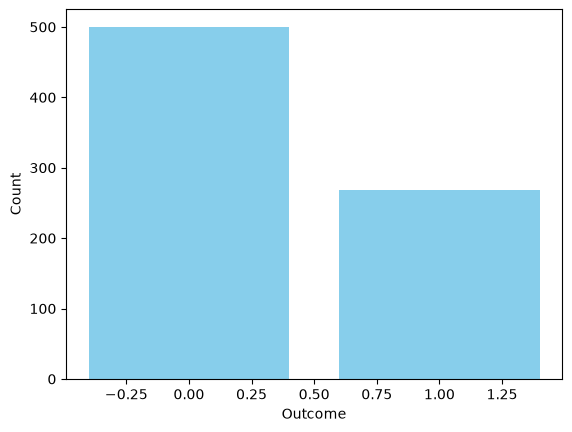

In [6]:
# Analyze the class distribution
class_counts = diabetes_data['Outcome'].value_counts() # insert code here 
print("Class Distribution:")
print(class_counts)

# Visualize the class distribution
plt.bar(class_counts.index, class_counts.values, color='skyblue')
# insert code here 
plt.xlabel('Outcome')  # Set x-axis label
plt.ylabel('Count')  # Set y-axis labe
# insert code here 

## Paso 8: Separando características y objetivo

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [7]:
# Features and target variable
x = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome'] #insert code here

# Split into training and testing sets with stratification
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

## Paso 9: Estandarizar características (escalado de características)

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [8]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
x_train_scaled

array([[-0.85135507, -0.98013068, -0.40478372, ..., -0.60767846,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842, ..., -0.30213902,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176, ...,  0.3725939 ,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.75815778,  0.03029235, ...,  0.77997981,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.31421198,  0.03029235, ..., -0.56948603,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.73223168, -0.62232176, ..., -0.31486983,
        -0.57700104,  0.30730824]], shape=(614, 8))

## Paso 10: Aplicar SMOTE a los datos de entrenamiento

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [10]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

smote.fit_resample() toma nuestras variables de entrenamiento estandarizadas y genera nuevos registros sintéticos para la clase minoritaria (pacientes con diabetes) hasta que haya exactamente el mismo número que en la clase mayoritaria (400 registros para cada una). De esta manera, el modelo aprenderá de forma equitativa.

## Paso 11: Visualizando la distribución de clases después de SMOTE

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

After SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


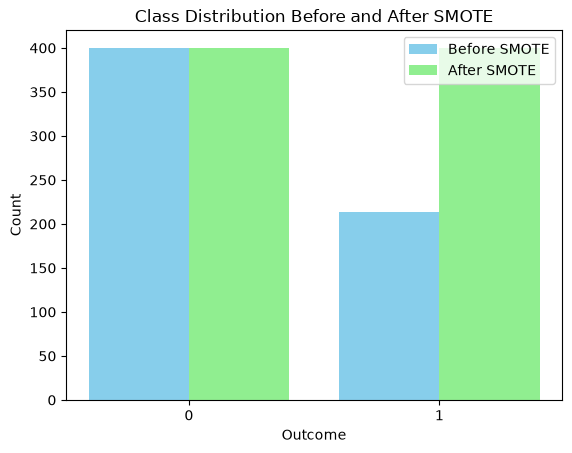

In [11]:
# Check the new class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Visualize the new class distribution
counts_before = y_train.value_counts()
counts_after = y_train_smote.value_counts()

plt.bar([0, 1], [counts_before.get(0, 0), counts_before.get(1, 0)], width=0.4, label='Before SMOTE', color='skyblue')
plt.bar([0.4, 1.4], [counts_after.get(0, 0), counts_after.get(1, 0)], width=0.4, label='After SMOTE', color='lightgreen')

plt.title('Class Distribution Before and After SMOTE')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks([0.2, 1.2], ['0', '1'])
plt.legend()
plt.show()

## Paso 12: Inicializar los modelos de regresión logística

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [12]:
# Initialize the models
model_orig = LogisticRegression(solver='liblinear', max_iter=200)
model_smote = LogisticRegression(solver='liblinear', max_iter=200)

## Paso 13: Entrenar los modelos

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [13]:
# Train the model on original data
model_orig.fit(x_train_scaled, y_train)

# Train the model on SMOTE data
model_smote.fit(x_train_smote, y_train_smote)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty

## Paso 14: Hacer predicciones y prepararse para evaluar modelos

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [14]:
# Make predictions on the test set
y_pred_orig = model_orig.predict(x_test_scaled)
y_pred_smote = model_smote.predict(x_test_scaled)

# Predictions probability for ROC-AUC
y_prob_orig = model_orig.predict_proba(x_test_scaled)[:, 1]
y_prob_smote = model_smote.predict_proba(x_test_scaled)[:, 1]

# Evaluate the model's performance
def evaluate_model(y_test, y_pred, y_prob):
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Paso 15: Evaluar el modelo en datos originales

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [15]:
print("Performance on Original Data:")
evaluate_model(y_test, y_pred_orig, y_prob_orig)

Performance on Original Data:
Accuracy: 0.7143
Precision: 0.6087
Recall: 0.5185
ROC-AUC: 0.8233

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



## Paso 16: Evaluar el modelo en datos aumentados con SMOTE

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


In [16]:
print("Performance on SMOTE Augmented Data:")
evaluate_model(y_test, y_pred_smote, y_prob_smote)

Performance on SMOTE Augmented Data:
Accuracy: 0.7403
Precision: 0.6129
Recall: 0.7037
ROC-AUC: 0.8204

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



|Métrica|Modelo con Datos Originales|Modelo con SMOTE| que paso?|
|:-----:|:-------------------------:|:--------------:|:--------:|
|Accuracy|~0.7078 (70.8%)|~0.7143 (71.4%)|Subió ligeramente.|
|Recall (Clase 1)|~0.4630 (46.3%)|~0.6296 (63.0%)|¡Aumentó drásticamente!|
|Precision (Clase 1)|~0.5952 (59.5%)|~0.5862 (58.6%)|Bajó una milésima insignificante.|

## Paso 17: Visualizar y comparar el rendimiento del modelo

Siga los pasos en el documento de instrucciones y ejecute la celda a continuación.


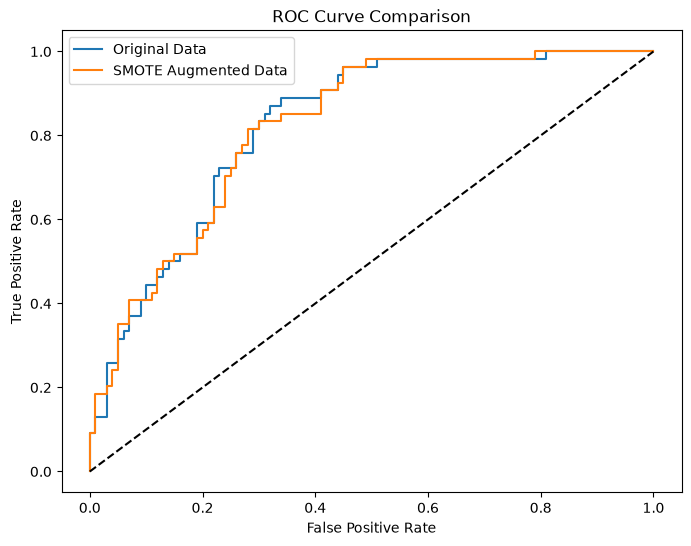

In [17]:
# Plot ROC curves
fpr_orig, tpr_orig, _ = roc_curve(y_test, y_prob_orig)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

plt.figure(figsize=(8, 6))
plt.plot(fpr_orig, tpr_orig, label='Original Data')
plt.plot(fpr_smote, tpr_smote, label='SMOTE Augmented Data')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Has llegado al final de este ejercicio.
